In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
c_guess_vals=[0.9791281505684851]
A_vals=[3.4342536609022134]

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def find_drive_frequency(A,f_supp,evolution,f_rabi,c_guess,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    c_vals=[]
    
    for i in range(min_range, max_range):
        f_1_shifted=f_1*(c_guess+i/scale)
        f_2_shifted=f_2*(c_guess+i/scale)

        c_vals.append(c_guess+i/scale)
        delta=qubit.frequency-2*f_1_shifted+f_2_shifted #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 3.3:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=10,U_f=15,f_2=f_2_shifted,K=200, drag=True)
        elif A < 3.8:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=10,U_f=10,f_2=f_2_shifted,K=200, drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=10,U_f=1,f_2=f_2_shifted,K=200, drag=True)
        
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    c=c_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(c,pi_pulse,[e_max,f_max],max_e_vals)

def find_params(f_1,f_2,f_supp,A,evolution,f_rabi,c_guess,AC_stark_supp,lims,scales,verbose=True):

    #Rajat AC-stark siirtymälle
    min_range_d = lims[0][0]
    max_range_d = lims[0][1]

    min_range_supp = lims[1][0]
    max_range_supp = lims[1][1]
    
    e_data=[]
    f_data=[]
    
    c_vals_d=np.arange(min_range_d,max_range_d)/scales[0]+c_guess
    AC_stark_vals_d=[2*f_1*(1-c)-f_2*(1-c) for c in c_vals_d]
    AC_stark_vals_supp=np.arange(min_range_supp,max_range_supp)/scales[1]+AC_stark_supp
    
    for i in range(min_range_d,max_range_d):
        c=c_guess+i/scales[0]
        f_1_opt=f_1*c
        f_2_opt=f_2*c

        max_e_vals=[]
        max_f_vals=[]
        
        for j in range(min_range_supp,max_range_supp):

            delta_supp=AC_stark_supp+j/scales[1] #AC-stark siirtymä
            f_supp1=(f_ef+delta_supp-2*f_1+f_2)/2+f_1
            f_supp2=f_ef+delta_supp-2*f_1+2*f_2
            
            sim_vals = pulses.sim_3_part_pulses(f_1_opt,[f_supp1,f_supp2],A,evolution,dim,f_rabi,t_ramp=10,U_f=1,f_2=f_2_opt,K=200,drag=True)
    
            max_e_vals.append(sim_vals[0])
            max_f_vals.append(sim_vals[1])

        e_data.append(max_e_vals)
        f_data.append(max_f_vals)

    xtick_locs=np.arange(0,1, step=0.2)*len(c_vals_d)
    ytick_locs=np.arange(0,1, step=0.2)*len(AC_stark_vals_supp)

    xlabels=[round(c_vals_d[int(i)],3) for i in xtick_locs]
    ylabels=[round(AC_stark_vals_supp[int(i)],3) for i in ytick_locs]

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(e_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_q-2ω_1+ω_2")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_supp-ω_ef")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="e-tason suurin todennäköisyys")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(f_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_q-2ω_1+ω_2")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_supp-ω_ef")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="f-tason suurin todennäköisyys")
    plt.show()

    if verbose:
        print(e_data)
        print(f_data)

    e_means = [np.mean(arr) for arr in e_data]
    e_index = np.argmax(e_means)
    f_index = np.argmin(f_data[e_index])
    
    delta_d=AC_stark_vals_d[e_index]
    c_d=c_vals_d[e_index]
    delta_supp=AC_stark_vals_supp[f_index]
    
    return(delta_d,delta_supp,c_d)

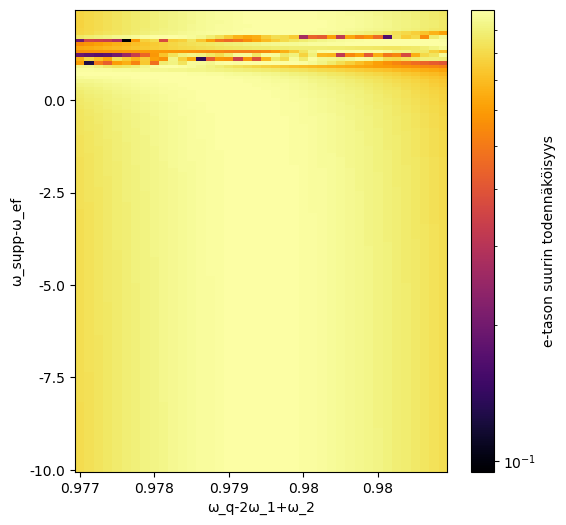

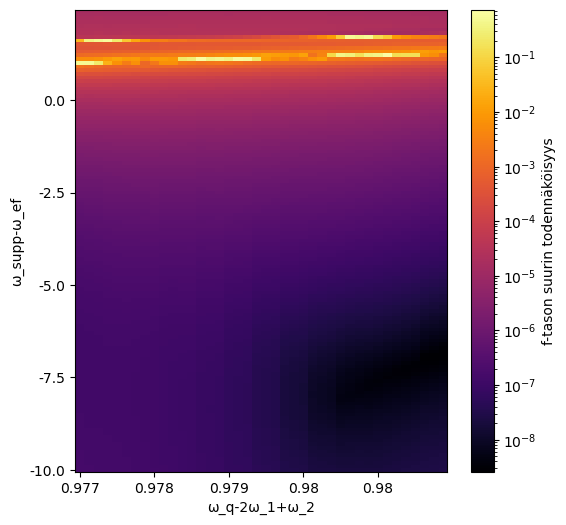

[[np.float64(0.8156945150902201), np.float64(0.8157372090954241), np.float64(0.8157807075210322), np.float64(0.815825033303554), np.float64(0.8158702102592618), np.float64(0.8159162631268954), np.float64(0.815963217612628), np.float64(0.8160111004378494), np.float64(0.8160599393898437), np.float64(0.8161097633749721), np.float64(0.8161606024762341), np.float64(0.8162124880134609), np.float64(0.8162654526068926), np.float64(0.8163195302466321), np.float64(0.8163747563637818), np.float64(0.8164311679087055), np.float64(0.8164888034328236), np.float64(0.816547703176169), np.float64(0.8166079091609261), np.float64(0.8166694652911461), np.float64(0.8167324174590757), np.float64(0.8167968136590832), np.float64(0.8168627041092507), np.float64(0.8169301413813675), np.float64(0.8169991805407015), np.float64(0.8170698792953578), np.float64(0.8171422981564856), np.float64(0.8172165006104226), np.float64(0.8172925533039755), np.float64(0.8173705262432058), np.float64(0.8174504930073424), np.float6

Amplitudi (GHz): 3.4342536609022134
Ajotaajuus AC Stark (GHz): 0.5294453902825209
Hiljennetty taajuus AC Stark (GHz): -8.2
E-tason suurin todennäköisyys: 0.9990344248329576
F-tason suurin todennäköisyys: 3.183690989206126e-08
Pulssin pituus (ns): 48.94994968373169


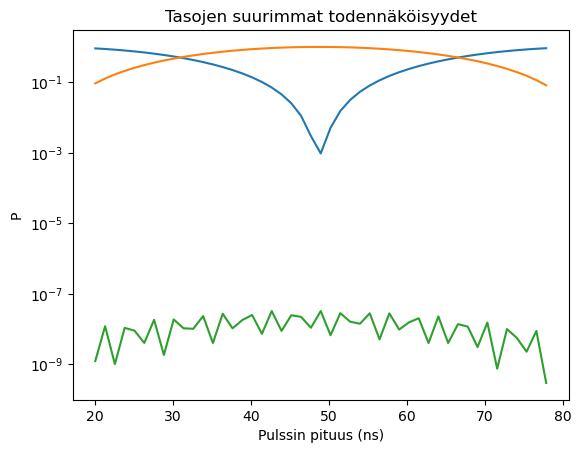

---------------------------------------------


In [7]:
f_supp=f_ef
A=A_vals[0]
f_rabi=2*np.pi/60

c_vals=[]
AC_stark_vals_d=[]
AC_stark_vals_supp=[]

params=find_params(f_1,f_2,f_supp,A,evolution_eigenbasis,f_rabi,c_guess_vals[0],0,[[-20,20],[-100,25]],[10000,10])
AC_stark_vals_d.append(params[0])
AC_stark_vals_supp.append(params[1])
c_vals.append(params[2])

f_supp1=(f_ef+AC_stark_vals_supp[-1]-2*f_1+f_2)/2+f_1
f_supp2=f_ef+AC_stark_vals_supp[-1]-2*f_1+2*f_2

m=1

vals = pulses.sim_3_part_pulses(f_1*params[2],[f_supp1,f_supp2],A,evolution_eigenbasis,dim,f_rabi/m,f_2=f_2*params[2],t_ramp=10,U_f=1,K=200,drag=True)

print("Amplitudi (GHz):", A)

print("Ajotaajuus AC Stark (GHz):", AC_stark_vals_d[-1])
print("Hiljennetty taajuus AC Stark (GHz):", AC_stark_vals_supp[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])
print("Pulssin pituus (ns):", vals[2])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

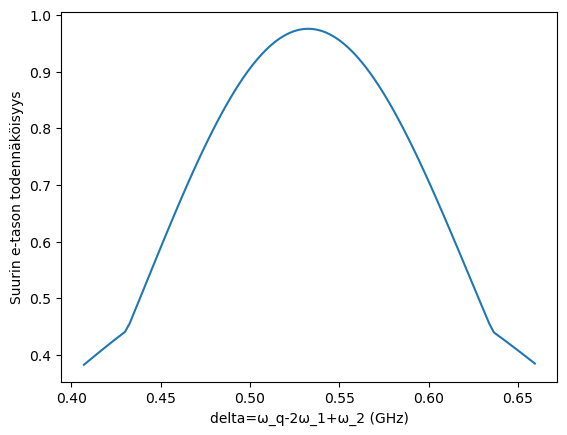

Amplitudi (GHz): 3.4342536609022134
AC-stark siirtymä (GHz): 0.5319942504214702
E-tason suurin todennäköisyys: 0.9998717638540727
F-tason suurin todennäköisyys: 3.4704497778635084e-08
Pulssin pituus (ns): 45.176440339688256


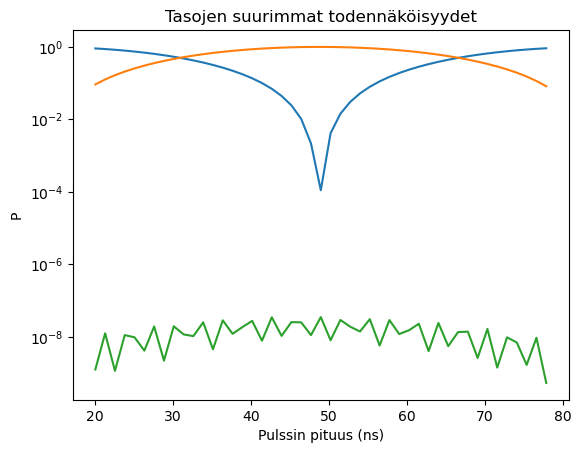

---------------------------------------------


In [8]:
params=find_drive_frequency(A,[f_supp1,f_supp2],evolution_eigenbasis,f_rabi,c_guess_vals[0],[-50,50],10000)

c_opt = params[0] #Löydetty optimaalinen ajotaajuus

m=1
vals = pulses.sim_3_part_pulses(f_1*c_opt,[f_supp1,f_supp2],A,evolution_eigenbasis,dim,f_rabi/m,f_2=f_2*c_opt,t_ramp=10,U_f=1,K=200,drag=True)

print("Amplitudi (GHz):", A)
print("AC-stark siirtymä (GHz):", 2*f_1*(1-c_opt)-f_2*(1-c_opt))

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])
print("Pulssin pituus (ns):", params[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

## Verrokkipulssi ilman dragia

Amplitudi (GHz): 3.4342536609022134
E-tason suurin todennäköisyys: 0.9999338741332018
F-tason suurin todennäköisyys: 3.335675740649336e-07
Pulssin pituus (ns): 48.9529063906415


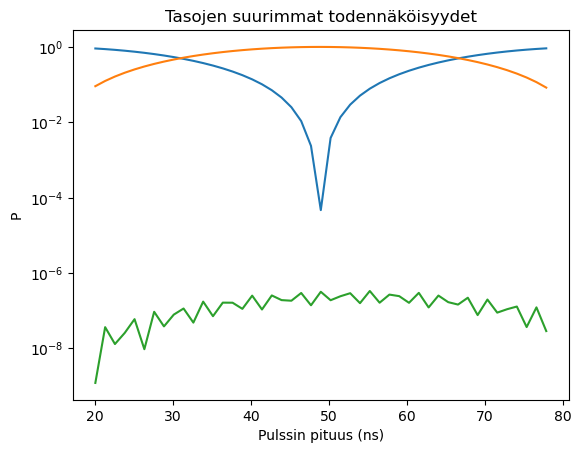

---------------------------------------------


In [9]:
m=1

vals = pulses.sim_3_part_pulses(f_1*c_guess_vals[0],[f_supp1,f_supp2],A,evolution_eigenbasis,dim,f_rabi/m,f_2=f_2*c_guess_vals[0],t_ramp=10,U_f=1,K=200,drag=False)

print("Amplitudi (GHz):", A)
print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])
print("Pulssin pituus (ns):", vals[2])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")